In [2]:
#import nesserary libraries for deep learning
from tensorflow import keras 
import numpy as np

#load dataset
from keras.datasets import mnist

#spliting the dataset into training and testing data
(x_train,y_train),(x_test,y_test)= mnist.load_data()

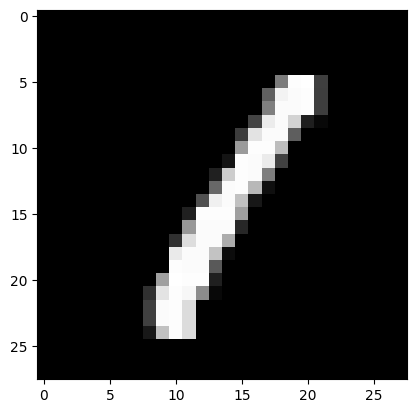

In [3]:
# display image for training data
import matplotlib.pyplot as plt
plt.imshow(x_train[3],cmap='gray')

In [7]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
x_train.ndim

3

In [11]:
# convert datatype of the data from int to float
x_train= x_train.astype('float32')
x_test= x_test.astype('float32')

In [12]:
#normalization of the data
x_train/=255
x_test/=255

In [14]:
# reshaping the data to fit the model
x_train= x_train.reshape(60000,784)
x_test= x_test.reshape(10000,784)

In [ ]:
print(x_train.shape)

(60000, 784)


In [19]:
print(x_test.shape)

(10000, 784)


In [21]:
# encoding the labels to one hot encoding
from keras.utils import to_categorical

y_train=to_categorical(y_train, num_classes=10)
y_test=to_categorical(y_test, num_classes=10)

In [24]:
print(y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [25]:
print(y_train.shape)

(60000, 10)


In [26]:
print(y_test[0])

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [27]:
print(y_test.shape)

(10000, 10)


In [29]:
# bulding the model
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation

model= Sequential()
model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(256,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 256)               33024     
                                                                 
 dense_2 (Dense)             (None, 256)               65792     
                                                                 
 dense_3 (Dense)             (None, 64)                16448     
                                                                 
 dense_4 (Dense)             (None, 10)                650       
                                                                 
Total params: 216394 (845.29 KB)
Trainable params: 216394 (845.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [33]:
#model comlilation
model.compile(loss="categorical_crossentropy",
              optimizer="sgd",
              metrics=['accuracy'] )

In [ ]:
#mode training
#اعمل رن بس مش هنا خليه علي GPU
model_trained= model.fit(x_train,y_train, validation_split=0.1,epochs=100, batch_size=128)

In [ ]:
# plot the training and validation accuracy and graph and loss
import matplotlib.pyplot as plt
plt.plot(model_trained.history['accuracy'])
plt.plot(model_trained.history['val_accuracy'])
plt.plot(model_trained.history['loss'])
plt.plot(model_trained.history['val_loss'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy', 'val_accuracy','loss','val_loss'], loc='upper left')
plt.show()

In [ ]:
#model evaluation
model.evaluate(x_test,y_test)

In [ ]:
#print the model accuracy
print(f"Model Accuracy: {round(test_acc, 2)}%")

In [ ]:
#print confusion matrix as plt
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
#print classification report
from sklearn.metrics import classification_report
print(classification_report(y_test.argmax(axis=1), y_pred.argmax(axis=1))))